### Question 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def bivar_norm(x_1, x_2, mu_1, mu_2, sig_1, sig_2, rho):
    z = (x_1 - mu_1) ** 2 / sig_1 ** 2 + (x_2 - mu_2) ** 2 / sig_2 ** 2
    - 2 * rho * (x_1 - mu_1) * (x_2 - mu_2) / sig_1 * sig_2
    denom = 2 * np.pi * sig_1 * sig_2 * np.sqrt(1 - rho ** 2)
    exponent = - z / (2 * (1 - rho ** 2))
    return np.exp(exponent) / denom

np.vectorize(bivar_norm)


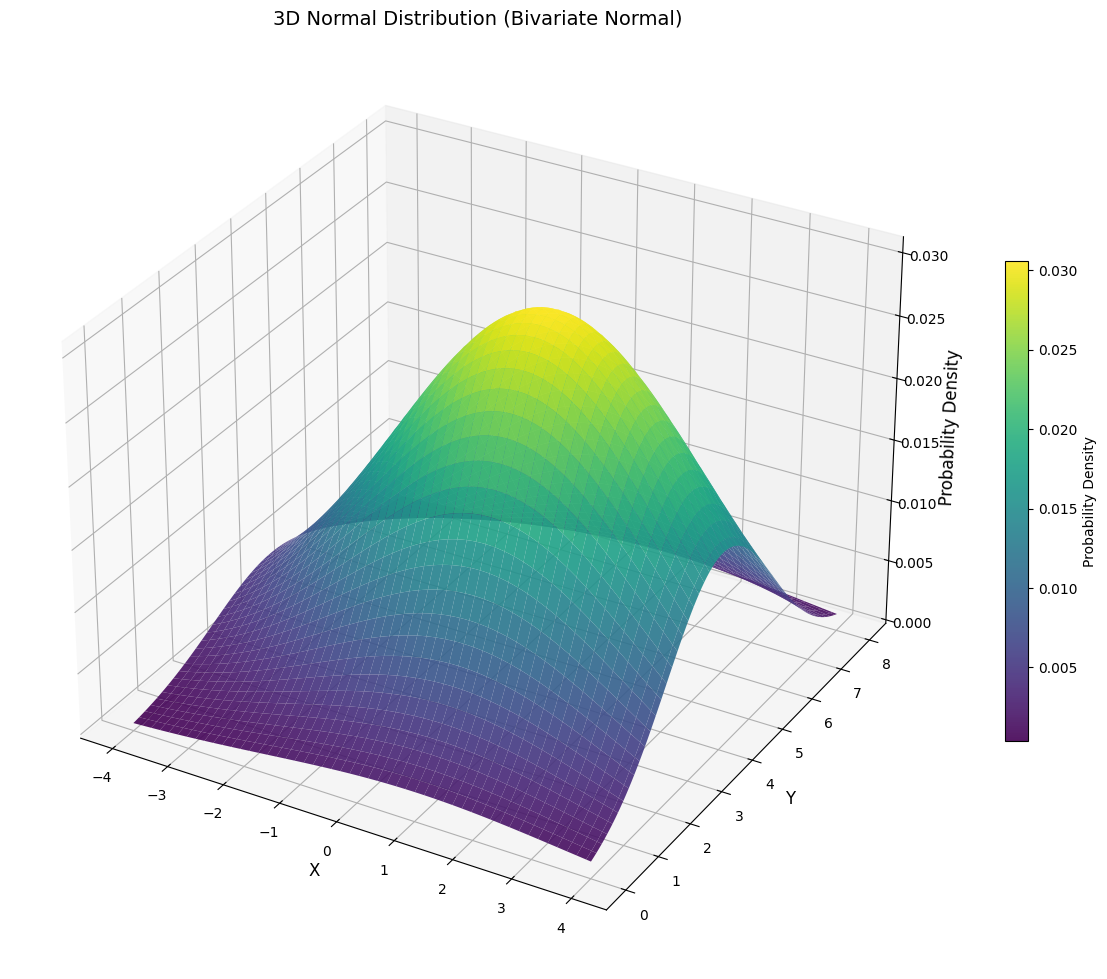

In [3]:
# Create a 3D normal distribution plot
# Parameters for the 2D normal distribution
mu_x, mu_y = 1, 4  # Mean
sigma_x, sigma_y = 3, 2  # Standard deviations
rho = 0.5  # Correlation coefficient

# Create a grid of x and y values
x = np.linspace(-4, 4, 100)
y = np.linspace(-0, 8, 100)
X, Y = np.meshgrid(x, y)

Z = bivar_norm(X, Y, mu_x, mu_y, sigma_x, sigma_y, rho)

# Create the 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create 3D surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9,
                        linewidth=0, antialiased=True, edgecolor='none')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20, label='Probability Density')

# Add labels and title
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Probability Density', fontsize=12)
ax.set_title('3D Normal Distribution (Bivariate Normal)', fontsize=14)

plt.tight_layout()
plt.show()


## Question 4

In [4]:
# (cosx)^2 generator

def cos2x_gen(x_start, x_stop, n):
        proposed_x = np.random.uniform(x_start, x_stop, n)
        simulated_y = np.cos(proposed_x) ** 2
        proposed_y = np.random.uniform(0, 1, n)

        # Efficiently retrieve all x values where proposed_y < simulated_y
        # Using boolean indexing - this is vectorized and very efficient
        accepted_x = proposed_x[proposed_y < simulated_y]

        return accepted_x

Generated 10976 accepted points


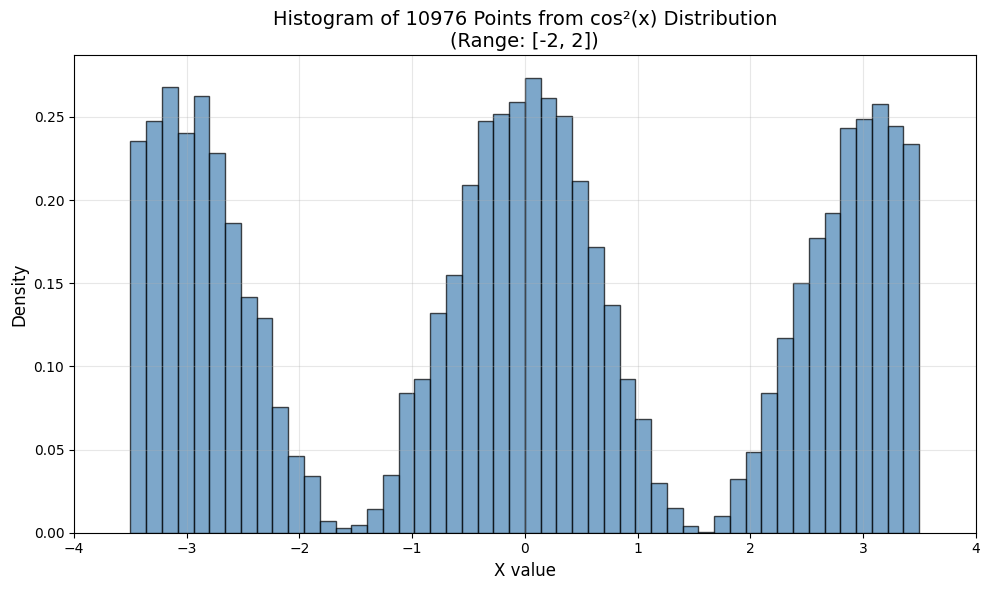

In [5]:
# Generate 1000 points from [-2, 2] using cos2x_gen and plot histogram
# Since rejection sampling may reject some points, generate more proposals
# to ensure we get at least 1000 accepted points
n_proposals = 20000  # Generate more to account for rejections
points_to_plot = cos2x_gen(-3.5, 3.5, n_proposals)


print(f"Generated {len(points_to_plot)} accepted points")
# print(f"Plotting {n_points} points")

# Create histogram (normalized so bars sum to 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(points_to_plot, bins=50, edgecolor='black', alpha=0.7, color='steelblue', density=True)
ax.set_xlabel('X value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Histogram of {len(points_to_plot)} Points from cos²(x) Distribution\n(Range: [-2, 2])', fontsize=14)
ax.set_xlim(-4, 4)  # Set x-axis range from -3 to 3
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
def sinxcosxplus2_gen(x_start, x_stop, n):
        proposed_x = np.random.uniform(x_start, x_stop, n)
        simulated_y = np.cos(proposed_x) + np.sin(proposed_x) + 2
        proposed_y = np.random.uniform(min(simulated_y), max(simulated_y), n)

        # Efficiently retrieve all x values where proposed_y < simulated_y
        # Using boolean indexing - this is vectorized and very efficient
        accepted_x = proposed_x[proposed_y < simulated_y]

        return accepted_x


Generated 9293 accepted points
Plotting 9293 points


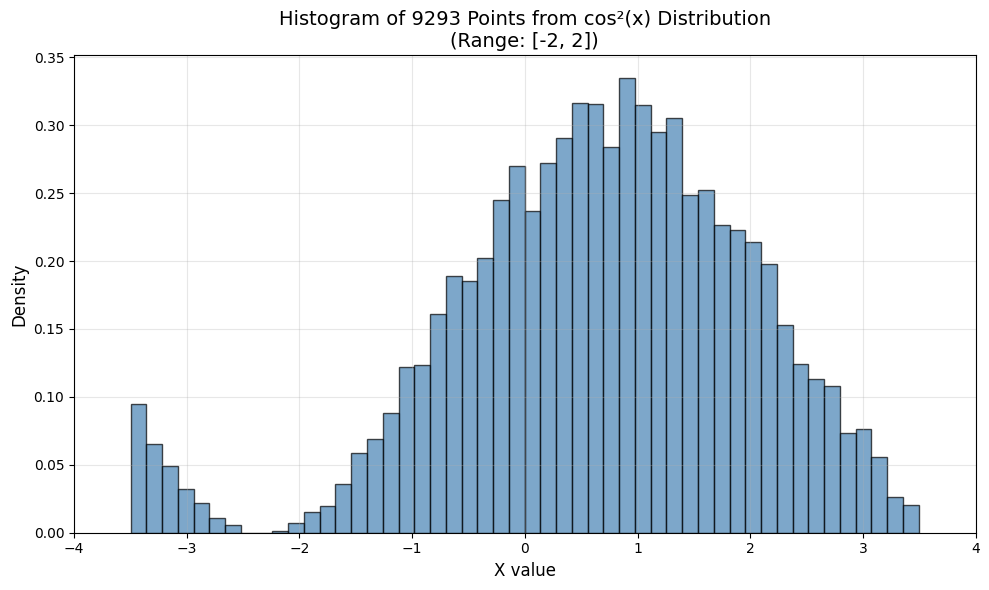

In [7]:
n_proposals = 20000  # Generate more to account for rejections
points_to_plot = sinxcosxplus2_gen(-3.5, 3.5, n_proposals)
n_points = points_to_plot.shape[0]

print(f"Generated {len(points_to_plot)} accepted points")
print(f"Plotting {n_points} points")

# Create histogram (normalized so bars sum to 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(points_to_plot, bins=50, edgecolor='black', alpha=0.7, color='steelblue', density=True)
ax.set_xlabel('X value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Histogram of {len(points_to_plot)} \
Points from cos²(x) Distribution\n(Range: [-2, 2])', fontsize=14)
ax.set_xlim(-4, 4)  # Set x-axis range from -3 to 3
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Generated 10956 accepted points
Plotting 9293 points


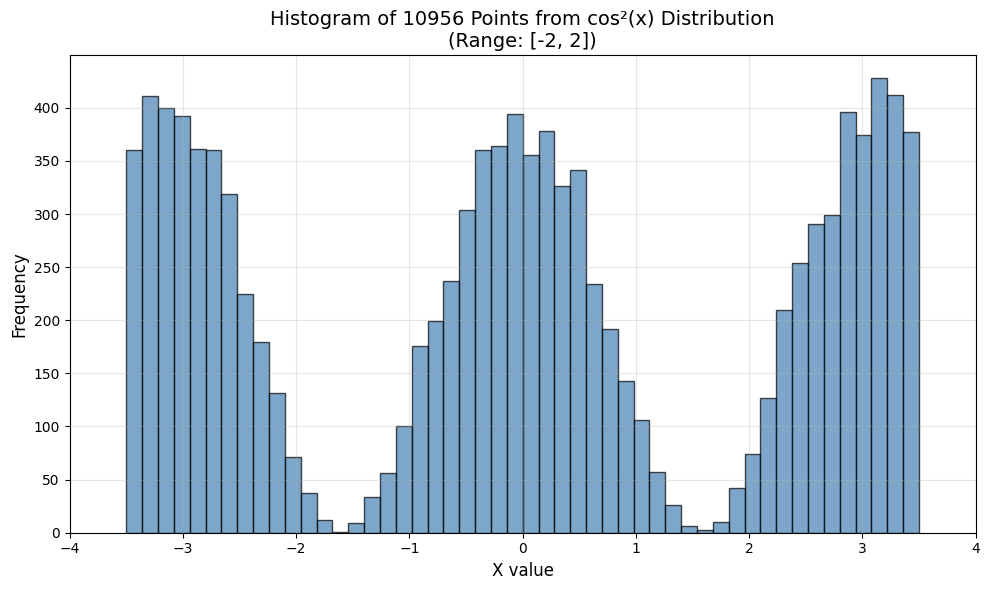

In [ ]:
def stdnorm_gen(x_start, x_stop, n):
        proposed_x = np.random.uniform(x_start, x_stop, n)
        simulated_y = np.exp(-(proposed_x ** 2)) / np.sqrt(np.pi * 2)
        proposed_y = np.random.uniform(min(simulated_y), max(simulated_y), n)

        # Efficiently retrieve all x values where proposed_y < simulated_y
        # Using boolean indexing - this is vectorized and very efficient
        accepted_x = proposed_x[proposed_y < simulated_y]

        return accepted_x

In [ ]:
eff = []
std_devs = list[int](range(1, 9))
n_proposals = 20000
for i in std_devs:
    n_accepted = stdnormgen(-i, i, n_proposals)
    eff.append(n_accepted.shape[0] / n_proposals)

NameError: name 'stdnorm_gen' is not defined

<class 'list'>
[1, 2, 3, 4, 5, 6, 7, 8]
[0.5986, 0.429, 0.29375, 0.22515, 0.17815, 0.15205, 0.1313, 0.11075]


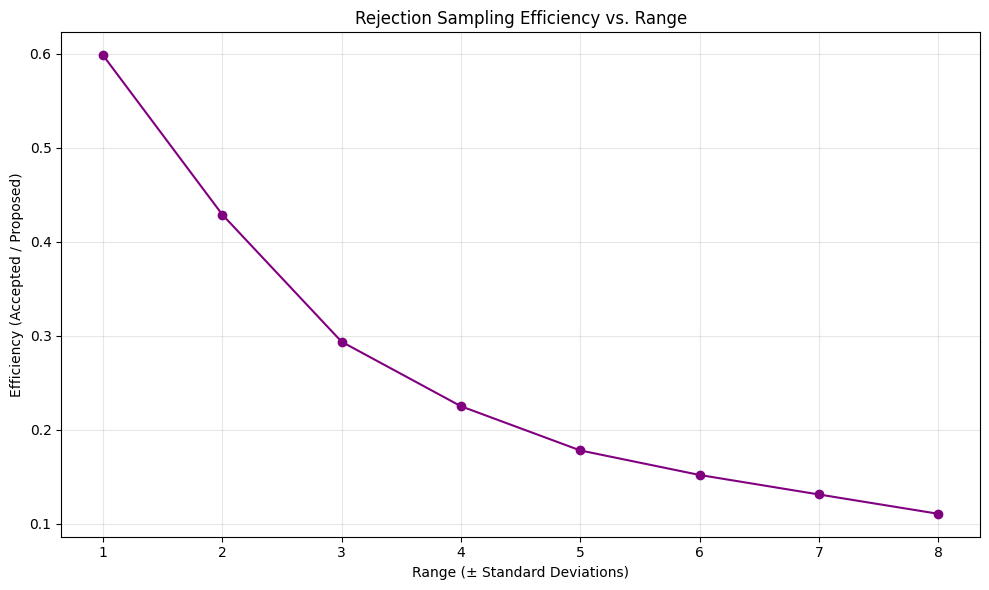

In [ ]:
print(type[int](std_devs))
print(std_devs)
print(eff)
plt.figure(figsize=(10, 6))
plt.plot(std_devs, eff, marker='o', linestyle='-', color='purple')
plt.xlabel('Range (± Standard Deviations)')
plt.ylabel('Efficiency (Accepted / Proposed)')
plt.title('Rejection Sampling Efficiency vs. Range')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
